# Spatially-Aware Clustering for Spatial Transcriptomics Data

Comparing clustering types, cluster granularity and spatial homogeneity with squidpy.

## Library imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq
from sklearn.mixture import GaussianMixture

/Users/selman/miniforge3/envs/squidpy/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


/Users/selman/miniforge3/envs/squidpy/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
/Users/selman/miniforge3/envs/squidpy/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left_exclusive = partial(_left_exclusive_join_spatialelement_table)
/Users/selman/miniforge3/envs/squidpy/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:533: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  inner = partial(_inner_join_spatialelement_table)
/Users/selman/mini

## Constants

In [2]:
seed = 42
resolution = 0.5

## Define functions

In [3]:
def align_clusters(adata, clustering_names):
    """Relabel every clustering to best match the first one, so colours are comparable."""
    from scipy.optimize import linear_sum_assignment

    obs = pd.DataFrame(adata.obs.copy())
    for cl in clustering_names[1:]:
        contingency_table = pd.crosstab(obs[cl], obs[clustering_names[0]])
        row_ind, col_ind = linear_sum_assignment(-contingency_table.values)
        mapping = dict(zip(contingency_table.index[row_ind], contingency_table.columns[col_ind], strict=False))
        # keep it categorical, otherwise integer labels plot as a continuous colour bar
        obs[cl] = pd.Categorical(obs[cl].map(mapping))
    adata.obs = obs
    return adata

## Data loading

In [4]:
adata = sq.datasets.visium_hne_adata()
adata

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

## Data preprocessing

In [5]:
sc.pp.pca(adata, n_comps=15)
sq.gr.spatial_neighbors_grid(adata, n_neighs=6)

# a fixed neighbourhood for measuring spatial homogeneity, independent of the graph used to cluster
sq.gr.spatial_neighbors_knn(adata, n_neighs=9, key_added="knn9")

INFO     Creating graph using `None` transform and `1` libraries.                                                  


INFO     Creating graph using `None` transform and `1` libraries.                                                  


## Non-spatial Clustering: Leiden

In [6]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=15, key_added="expr")
sc.tl.leiden(adata, resolution=resolution, flavor="igraph", n_iterations=2, directed=False, neighbors_key="expr")
adata.obs["leiden"] = pd.Categorical(adata.obs["leiden"].astype(int))
adata.obs["leiden"].value_counts()

leiden
6     415
4     307
2     286
0     279
11    272
9     258
7     193
3     174
8     158
1     152
5     124
12     39
10     31
Name: count, dtype: int64

## Neighborhood-profile Clustering

In [7]:
sq.gr.calculate_niche_neighborhood(adata, groups="cluster", resolutions=resolution, distance=2, seed=seed)
adata.obs["nhood"] = pd.Categorical(adata.obs.pop(f"nhood_niche_res={resolution}").astype(int))
adata.obs["nhood"].value_counts()

/Users/selman/miniforge3/envs/squidpy/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


nhood
6     185
5     182
19    147
4     141
9     139
10    137
23    133
22    114
27    110
12    107
0     107
16    100
3      96
29     93
18     72
25     65
1      63
2      63
11     57
32     52
24     50
7      45
30     45
8      44
14     44
20     43
26     42
28     37
17     33
31     31
13     30
21     23
34     23
15     20
33     15
Name: count, dtype: int64

## Aggregation-based Clustering: CellCharter

In [8]:
sq.gr.calculate_niche_cellcharter(
    adata,
    distance=2,
    aggregation="mean",
    n_clusters=adata.obs["leiden"].nunique(),
    use_rep="X_pca",
    n_components=15,
    seed=seed,
)
adata.obs["cellcharter"] = pd.Categorical(adata.obs.pop("cellcharter_niche").astype(int))
adata.obs["cellcharter"].value_counts()

cellcharter
7     544
8     312
2     244
5     243
10    216
0     211
9     157
4     148
11    143
6     133
3     116
12    112
1     109
Name: count, dtype: int64

# How to cluster for SRT
## Know your type: Different clustering types

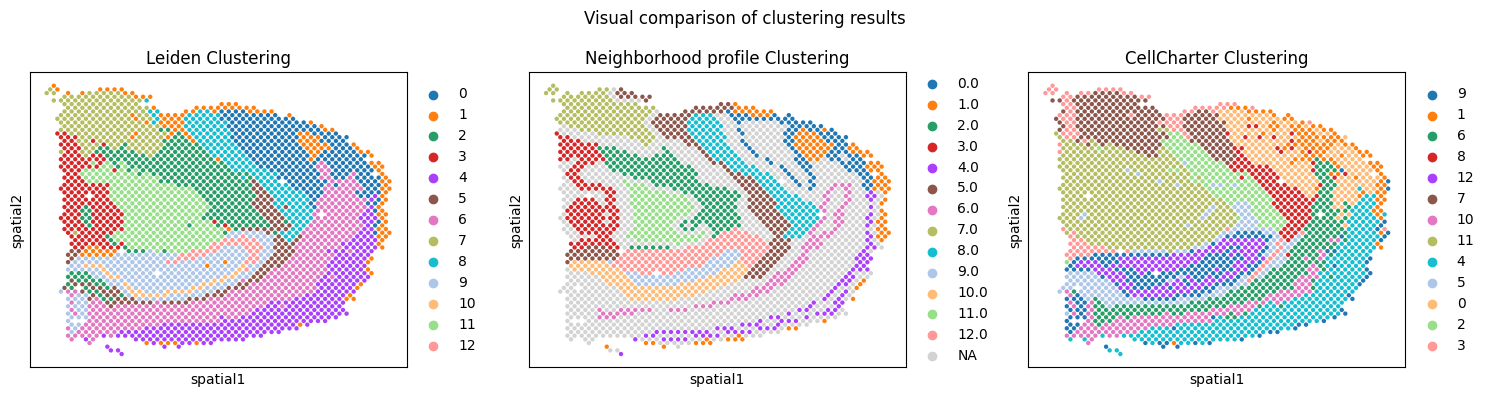

In [9]:
adata = align_clusters(adata, ["leiden", "nhood", "cellcharter"])

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, name, title in zip(
    axs, ["leiden", "nhood", "cellcharter"], ["Leiden", "Neighborhood profile", "CellCharter"], strict=True
):
    sc.pl.embedding(adata, basis="spatial", color=name, ax=ax, show=False, size=40)
    ax.set_title(f"{title} Clustering")

fig.suptitle("Visual comparison of clustering results")
fig.tight_layout()
plt.show()

## Parameter: Cluster granularity

In [10]:
cluster_numbers = range(2, 13)
seed_list = [1999, 2000, 2001, 2002, 2003, 2004]

for n_clust in cluster_numbers:
    for s in seed_list:
        gmm = GaussianMixture(n_components=n_clust, random_state=s, init_params="random_from_data", reg_covar=1e-4)
        adata.obs[f"gmm_{n_clust}_seed_{s}"] = pd.Categorical(gmm.fit_predict(adata.obsm["X_pca"]))

cluster_keys = {n_clust: [f"gmm_{n_clust}_seed_{s}" for s in seed_list] for n_clust in cluster_numbers}

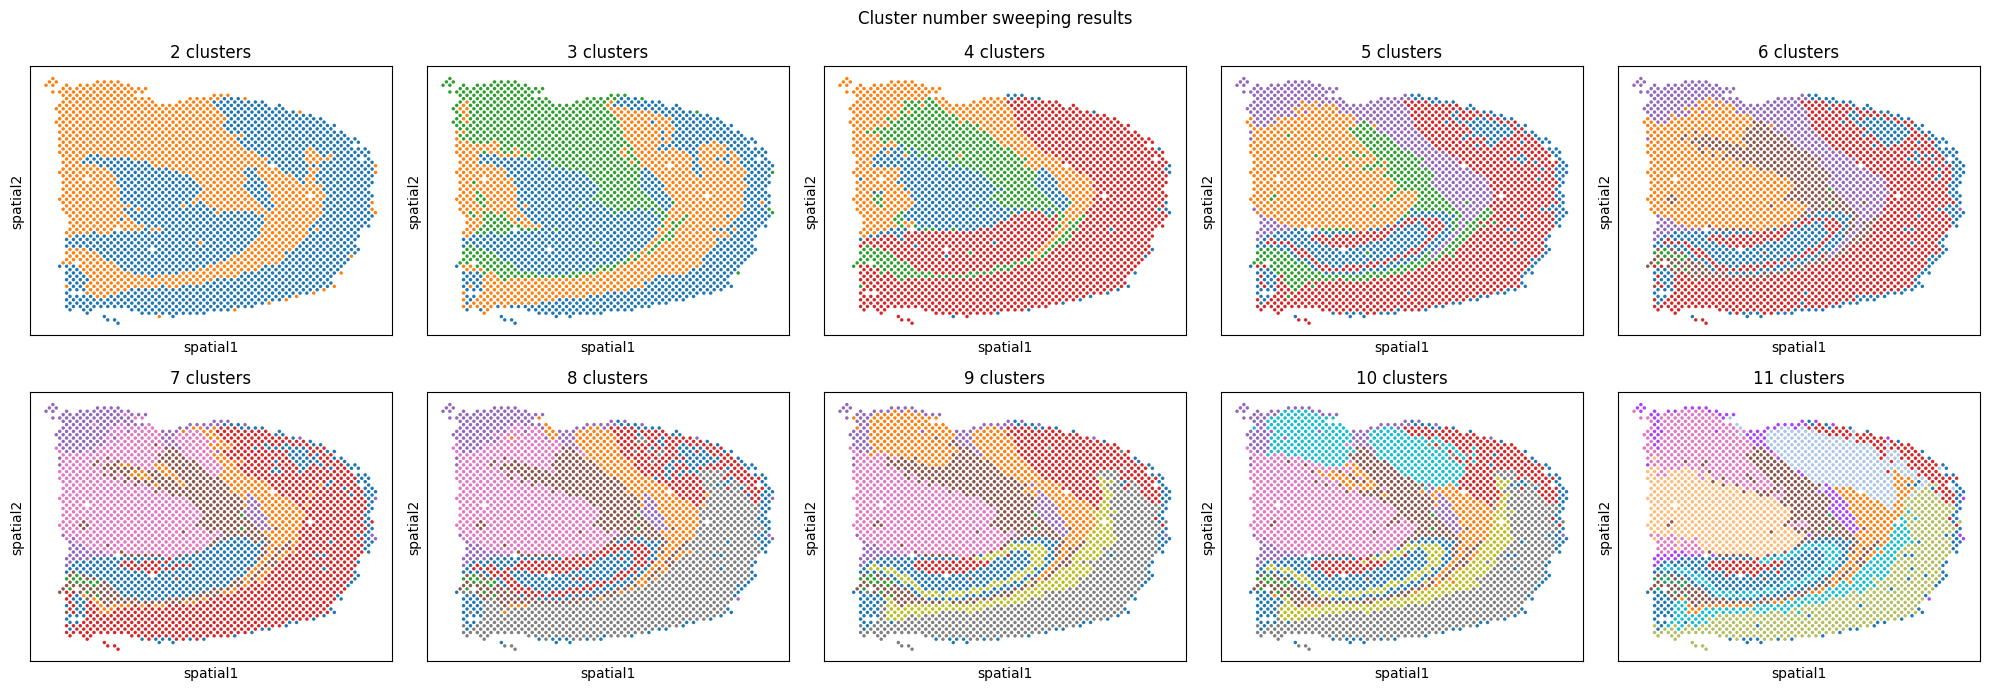

In [11]:
fig, axs = plt.subplots(2, 5, figsize=(20, 7))
for ax, n_clust in zip(axs.flatten(), list(cluster_numbers)[:10], strict=True):
    sc.pl.embedding(
        adata, basis="spatial", color=f"gmm_{n_clust}_seed_{seed_list[0]}",
        ax=ax, show=False, size=25, legend_loc=None,
    )
    ax.set_title(f"{n_clust} clusters")

fig.suptitle("Cluster number sweeping results")
fig.tight_layout()
plt.show()

In [12]:
stab_df = sq.gr.cluster_stability(adata, cluster_keys, copy=True)
stab_df.round(3)

INFO     Scoring the stability of K=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] over 6 runs each                          


,stability_mean,stability_std,is_peak,is_best
k,,,,
2,NaN,NaN,False,False
3,0.742,0.107,False,True
4,0.709,0.093,False,False
5,0.644,0.067,False,False
6,0.616,0.077,False,False
7,0.589,0.093,False,False
8,0.563,0.085,False,False
9,0.550,0.058,False,False
10,0.565,0.051,False,False


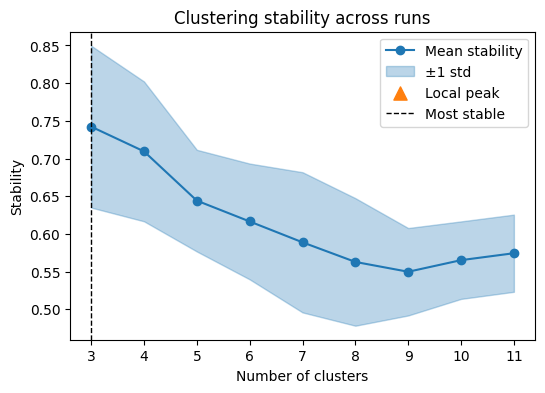

In [13]:
interior = stab_df.dropna(subset=["stability_mean"])
x = interior.index
y = interior["stability_mean"]
err = interior["stability_std"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, y, marker="o", color="C0", label="Mean stability")
ax.fill_between(x, y - err, y + err, color="C0", alpha=0.3, label="±1 std")
ax.scatter(
    interior.index[interior["is_peak"]], y[interior["is_peak"]],
    marker="^", s=90, color="C1", zorder=3, label="Local peak",
)
ax.axvline(int(stab_df.index[stab_df["is_best"]][0]), ls="--", c="k", lw=1, label="Most stable")

ax.set_xlabel("Number of clusters")
ax.set_ylabel("Stability")
ax.set_title("Clustering stability across runs")
ax.legend()
plt.show()

`sq.gr.cluster_auto_k` runs the same sweep and fits the mixtures itself.

In [14]:
res = sq.gr.cluster_auto_k(
    adata, n_clusters=(3, 11), use_rep="X_pca", max_runs=6, seed=seed, model_params={"reg_covar": 1e-4}
)
print(f"best_k={res.best_k}  peaks={res.peaks}  n_runs={res.n_runs}  converged={res.converged}")
res.to_frame().round(3)

INFO     Selecting the number of clusters over K=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12] with up to 6 runs each (66   
         mixture fits at most)                                                                                     


INFO     Selected K=3 after 6 runs (peaks at K=[10])                                                               


best_k=3  peaks=[10]  n_runs=6  converged=False


,stability_mean,stability_std,nll,is_peak,is_best
k,,,,,
2,NaN,NaN,32.453,False,False
3,0.710,0.104,30.412,False,True
4,0.679,0.089,29.172,False,False
5,0.629,0.076,28.249,False,False
6,0.577,0.089,27.649,False,False
7,0.552,0.088,27.235,False,False
8,0.541,0.082,26.756,False,False
9,0.545,0.073,26.582,False,False
10,0.558,0.067,26.030,True,False


## Parameter: Spatial homogeneity

- Run cluster results with different smoothing parameters
- Run spatial entropy for heterogenous regions

In [15]:
aggregation_distances = [1, 2, 3, 5, 8]

for d in aggregation_distances:
    sq.gr.calculate_niche_neighborhood(adata, groups="cluster", resolutions=resolution, distance=d, seed=seed)
    adata.obs[f"nhood_distance_{d}"] = pd.Categorical(adata.obs.pop(f"nhood_niche_res={resolution}"))
    sq.gr.nhood_entropy(adata, f"nhood_distance_{d}", connectivity_key="knn9_connectivities")

adata = align_clusters(adata, [f"nhood_distance_{d}" for d in aggregation_distances[::-1]])

/Users/selman/miniforge3/envs/squidpy/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/Users/selman/miniforge3/envs/squidpy/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/Users/selman/miniforge3/envs/squidpy/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


/Users/selman/miniforge3/envs/squidpy/lib/python3.13/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


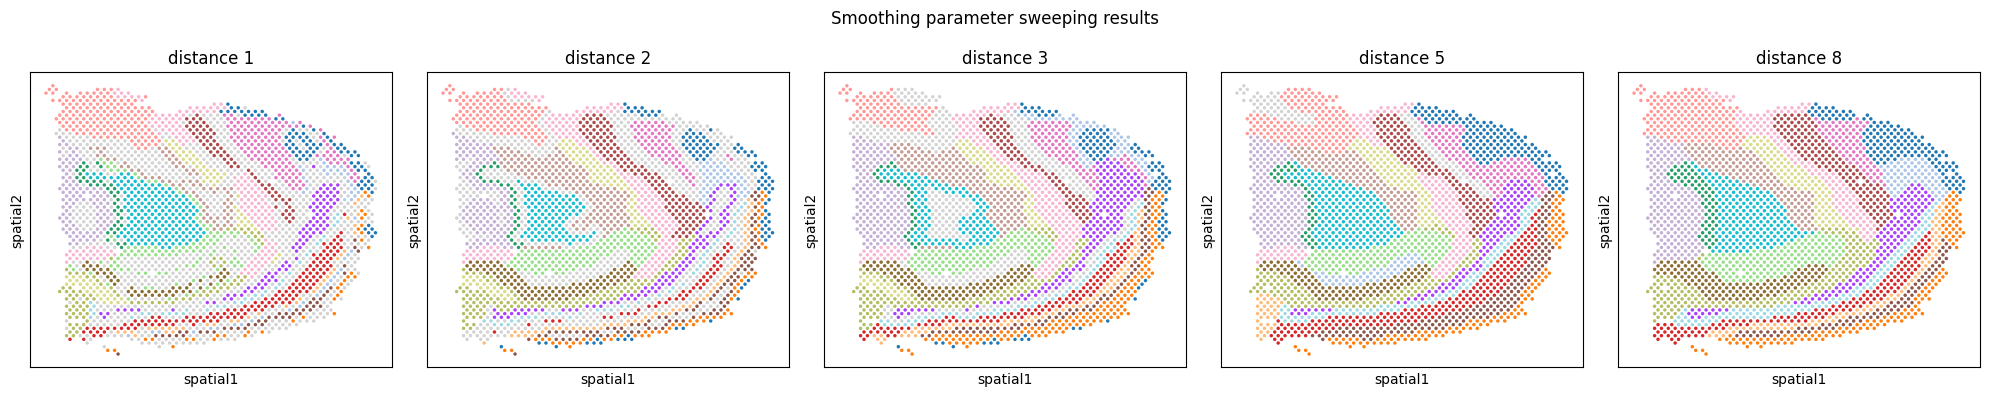

In [16]:
fig, axs = plt.subplots(1, len(aggregation_distances), figsize=(4 * len(aggregation_distances), 4))
for ax, d in zip(axs, aggregation_distances, strict=True):
    sc.pl.embedding(
        adata, basis="spatial", color=f"nhood_distance_{d}", ax=ax, show=False, size=25, legend_loc=None
    )
    ax.set_title(f"distance {d}")

fig.suptitle("Smoothing parameter sweeping results")
fig.tight_layout()
plt.show()

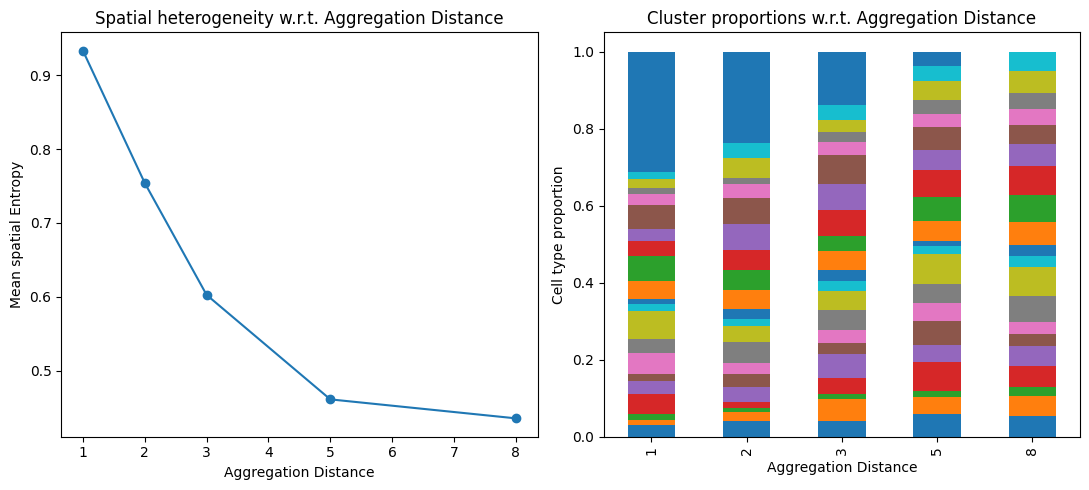

In [17]:
mean_entropy = [adata.obs[f"nhood_distance_{d}_nhood_entropy"].mean() for d in aggregation_distances]

cl_prop = pd.melt(
    adata.obs, id_vars=[],
    value_vars=[f"nhood_distance_{d}" for d in aggregation_distances],
    var_name="Aggregation_Distance", value_name="Cluster",
)
cl_prop["Aggregation_Distance"] = cl_prop["Aggregation_Distance"].str.replace("nhood_distance_", "").astype(int)
cl_prop["Cluster"] = cl_prop["Cluster"].astype(str)
cl_prop = cl_prop.groupby("Aggregation_Distance")["Cluster"].value_counts(normalize=True).sort_index().unstack()

fig, axs = plt.subplots(1, 2, figsize=(11, 5))

axs[0].plot(aggregation_distances, mean_entropy, marker="o")
axs[0].set_xlabel("Aggregation Distance")
axs[0].set_ylabel("Mean spatial Entropy")
axs[0].set_title("Spatial heterogeneity w.r.t. Aggregation Distance")

cl_prop.plot.bar(stacked=True, ax=axs[1], legend=False)
axs[1].set_xlabel("Aggregation Distance")
axs[1].set_ylabel("Cell type proportion")
axs[1].set_title("Cluster proportions w.r.t. Aggregation Distance")

fig.tight_layout()
plt.show()

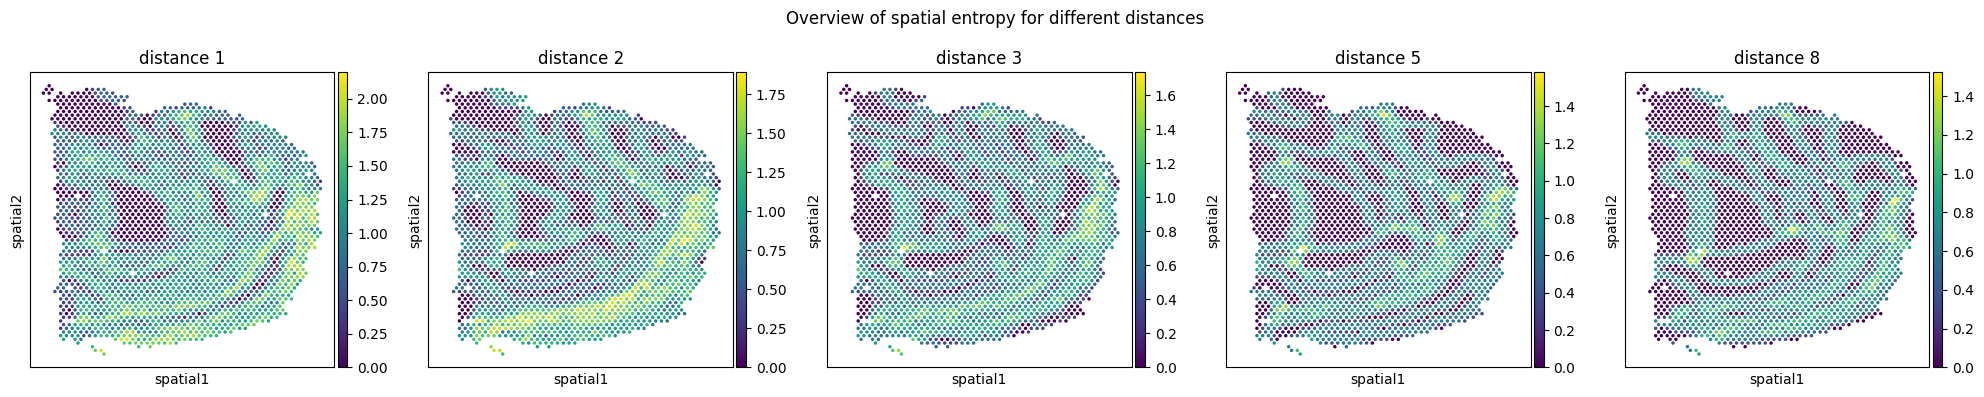

In [18]:
fig, axs = plt.subplots(1, len(aggregation_distances), figsize=(4 * len(aggregation_distances), 4))
for ax, d in zip(axs, aggregation_distances, strict=True):
    sc.pl.embedding(
        adata, basis="spatial", color=f"nhood_distance_{d}_nhood_entropy", ax=ax, show=False, size=25
    )
    ax.set_title(f"distance {d}")

fig.suptitle("Overview of spatial entropy for different distances")
fig.tight_layout()
plt.show()

# Epilog